In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

PATH = "/Users/herjimenez/Documents/MAESTRIA/PROYECTOS/Trabajo de grado/KMC-70k-93-2024-Malnutricion-conVel-DATA-SPSS-20250322.xlsx"
df_raw = pd.read_excel(PATH)
df = df_raw.replace('#NULL!', np.nan).copy()

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")


Dimensiones: 64,801 filas × 753 columnas


## 1. Variable Objetivo: `preterm`

=== Distribución de preterm ===
  0 - No prematuro : 16,465  (25.4%)
  1 - Prematuro    : 48,320  (74.6%)
  NaN              :     16


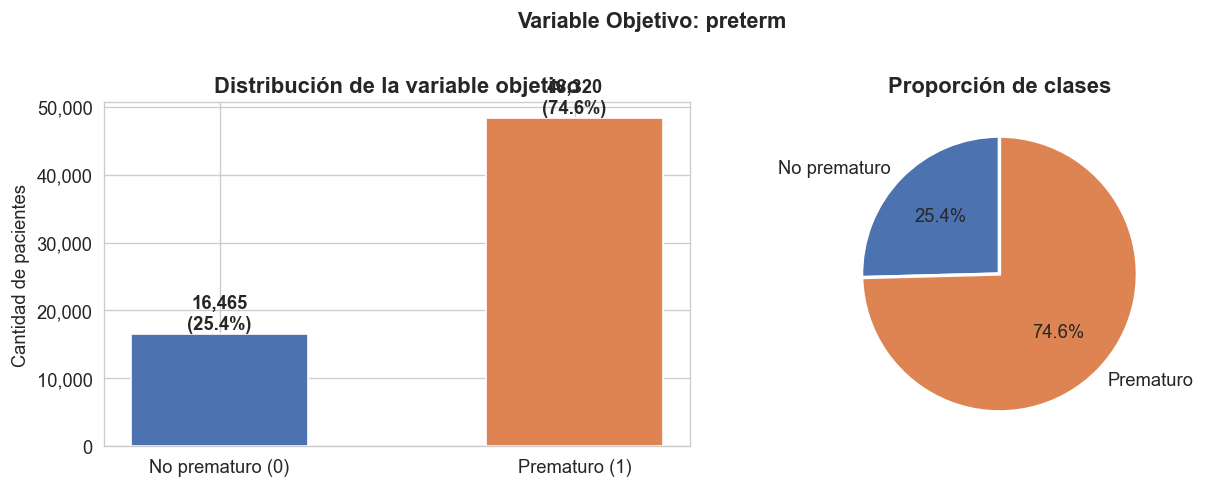

⚠️  Desbalance de clases detectado: ratio aprox. 3:1 (prematuro vs no prematuro)


In [2]:

df['preterm'] = pd.to_numeric(df['preterm'], errors='coerce')
target = df['preterm'].dropna()

counts = target.value_counts().sort_index()
pct    = target.value_counts(normalize=True).sort_index() * 100

print("=== Distribución de preterm ===")
print(f"  0 - No prematuro : {counts[0]:>6,}  ({pct[0]:.1f}%)")
print(f"  1 - Prematuro    : {counts[1]:>6,}  ({pct[1]:.1f}%)")
print(f"  NaN              : {df['preterm'].isna().sum():>6,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(['No prematuro (0)', 'Prematuro (1)'], counts.values,
                   color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar, v, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de la variable objetivo', fontweight='bold')
axes[0].set_ylabel('Cantidad de pacientes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(counts.values, labels=['No prematuro', 'Prematuro'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporción de clases', fontweight='bold')

plt.suptitle('Variable Objetivo: preterm', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/herjimenez/Documents/MAESTRIA/PROYECTOS/Trabajo de grado/eda_01_target.png',
            bbox_inches='tight')
plt.show()
print("⚠️  Desbalance de clases detectado: ratio aprox. 3:1 (prematuro vs no prematuro)")


## 2. Análisis de Valores Nulos

=== Distribución de nulos por columna ===
  Sin nulos (0%)        :   1 cols (0.1%) 
  Bajo (1-25%)          : 261 cols (34.7%) █████████████████
  Medio (26-50%)        : 181 cols (24.0%) ████████████
  Alto (51-75%)         : 226 cols (30.0%) ███████████████
  Muy alto (>75%)       :  84 cols (11.2%) █████


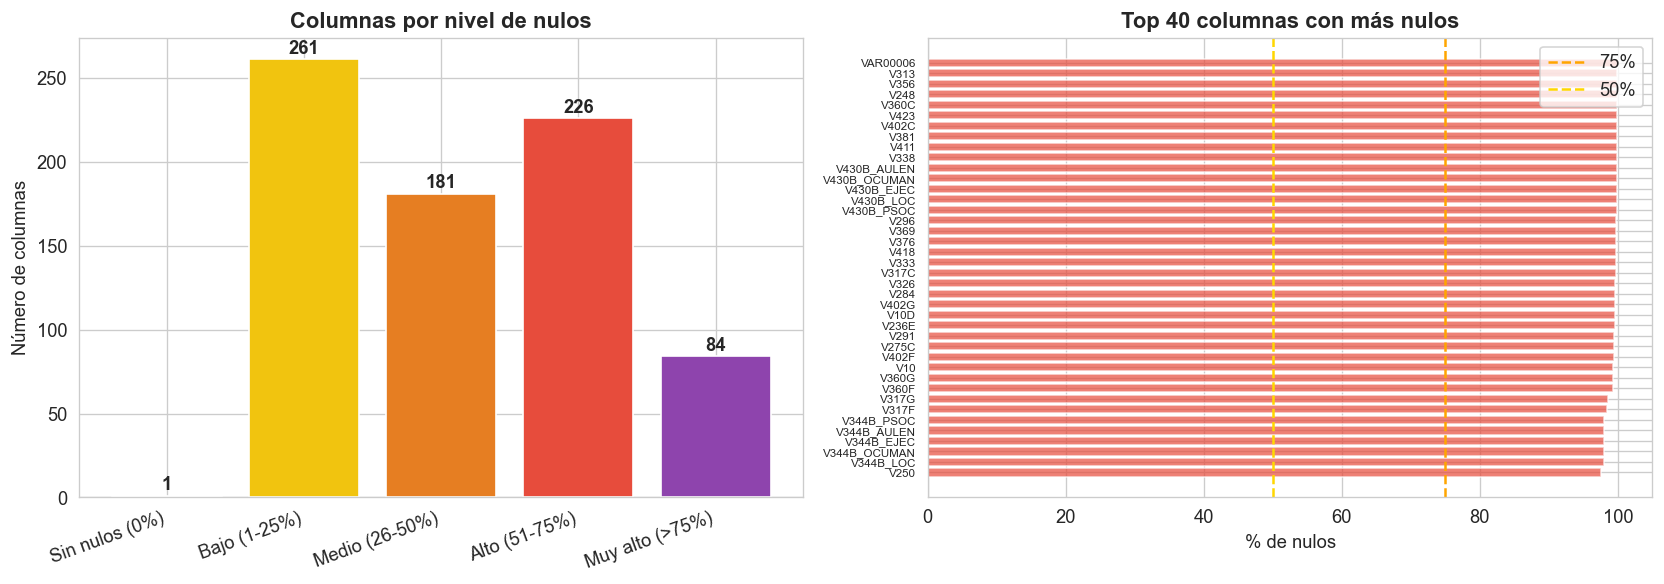

In [3]:

null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

buckets = {
    'Sin nulos (0%)':       (null_pct == 0).sum(),
    'Bajo (1-25%)':         ((null_pct > 0)  & (null_pct <= 25)).sum(),
    'Medio (26-50%)':       ((null_pct > 25) & (null_pct <= 50)).sum(),
    'Alto (51-75%)':        ((null_pct > 50) & (null_pct <= 75)).sum(),
    'Muy alto (>75%)':      (null_pct > 75).sum(),
}

print("=== Distribución de nulos por columna ===")
for k, v in buckets.items():
    pct_col = v / len(df.columns) * 100
    bar = '█' * int(pct_col / 2)
    print(f"  {k:<22}: {v:>3} cols ({pct_col:.1f}%) {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart by bucket
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
bars = axes[0].bar(buckets.keys(), buckets.values(), color=colors, edgecolor='white')
axes[0].set_title('Columnas por nivel de nulos', fontweight='bold')
axes[0].set_ylabel('Número de columnas')
axes[0].set_xticklabels(buckets.keys(), rotation=20, ha='right')
for bar, v in zip(bars, buckets.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', va='bottom', fontweight='bold')

# Top 40 columns with most nulls
top40 = null_pct.head(40)
axes[1].barh(range(len(top40)), top40.values[::-1], color='#e74c3c', alpha=0.7)
axes[1].set_yticks(range(len(top40)))
axes[1].set_yticklabels(top40.index[::-1], fontsize=7)
axes[1].axvline(75, color='orange', linestyle='--', label='75%')
axes[1].axvline(50, color='gold', linestyle='--', label='50%')
axes[1].set_title('Top 40 columnas con más nulos', fontweight='bold')
axes[1].set_xlabel('% de nulos')
axes[1].legend()

plt.tight_layout()
plt.savefig('/Users/herjimenez/Documents/MAESTRIA/PROYECTOS/Trabajo de grado/eda_02_nulos.png',
            bbox_inches='tight')
plt.show()


## 3. Variables Clave relacionadas con Prematurez

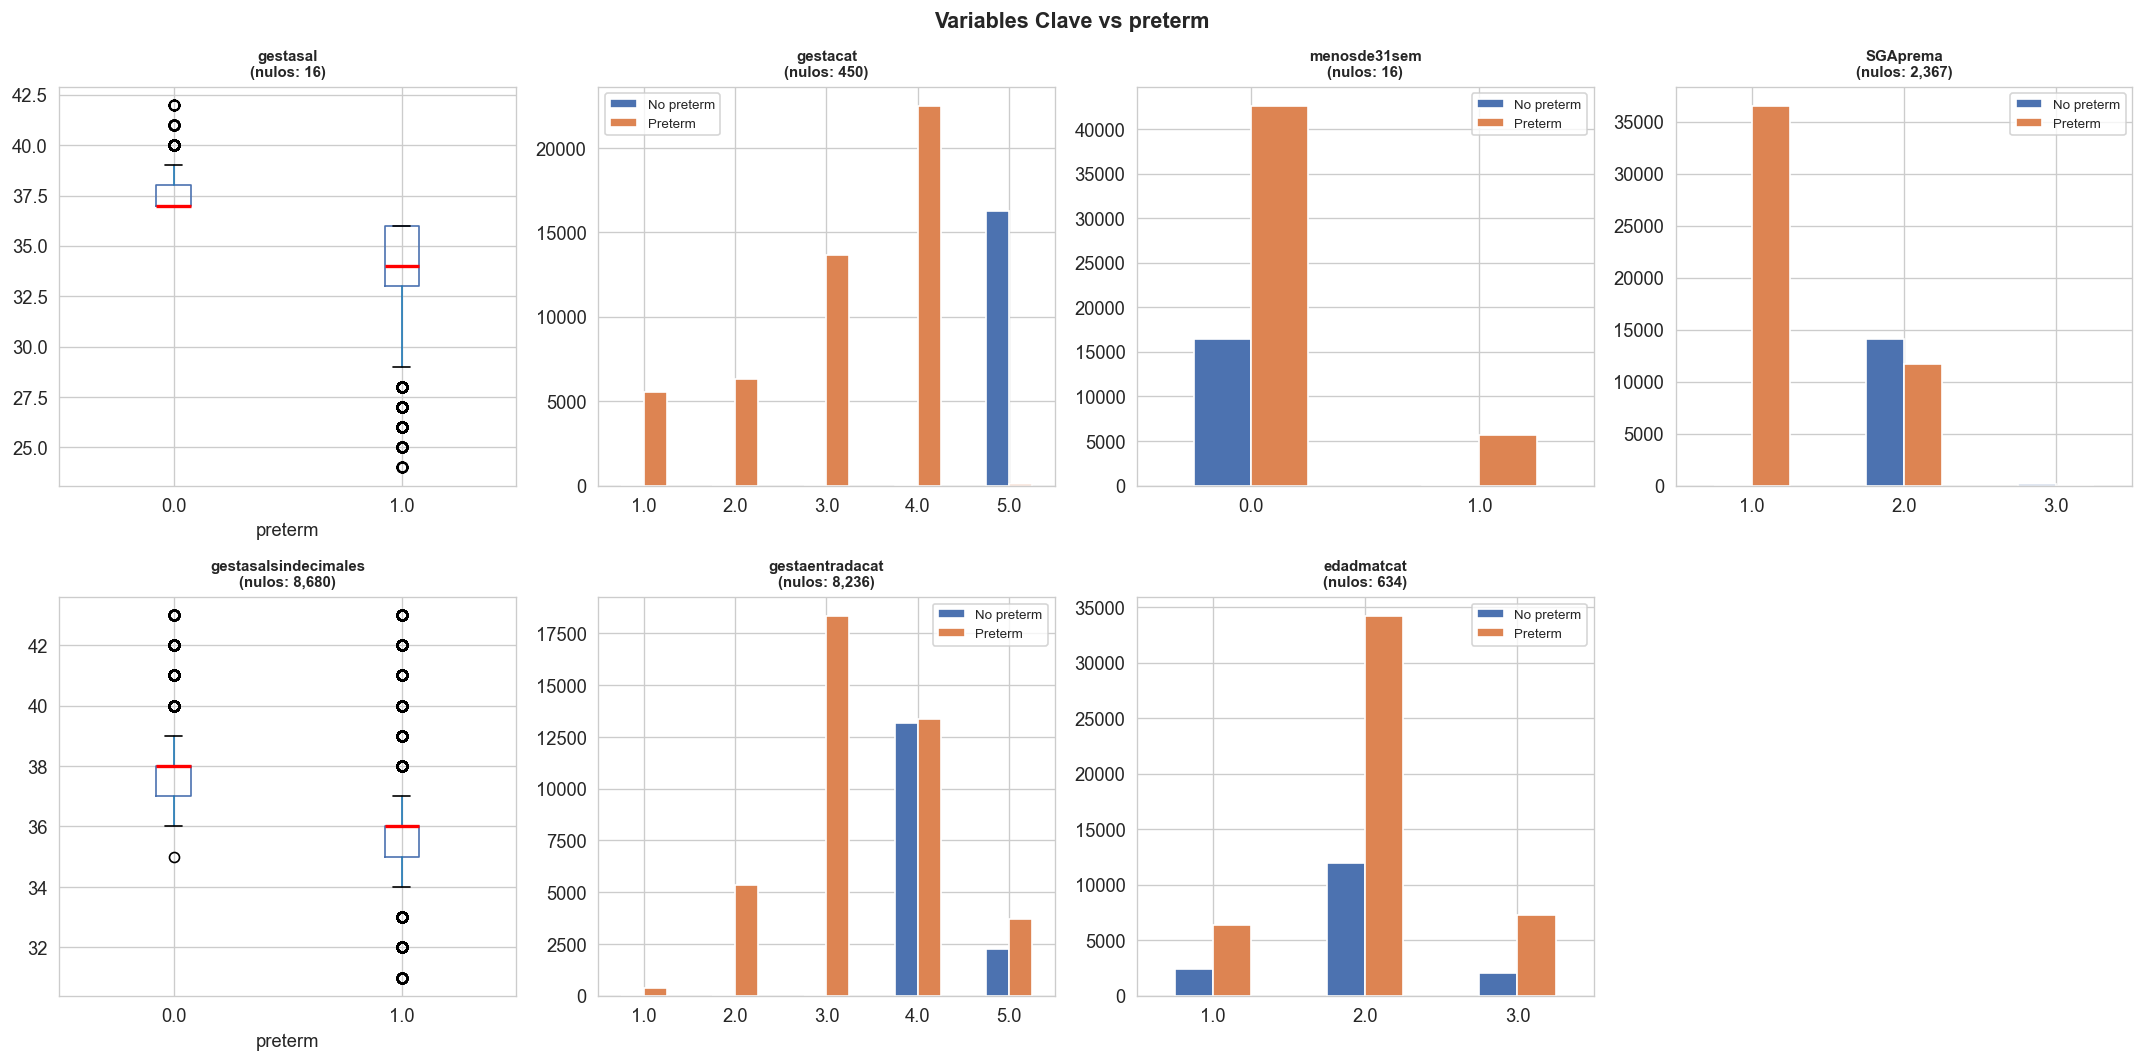

In [4]:

key_vars = ['gestasal', 'gestacat', 'menosde31sem', 'SGAprema',
            'gestasalsindecimales', 'gestaentradacat', 'edadmatcat']

for col in key_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    ax = axes[i]
    if df[col].nunique() <= 10:
        data = df.groupby([col, 'preterm']).size().unstack(fill_value=0)
        data.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', rot=0)
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(['No preterm', 'Preterm'], fontsize=8)
    else:
        df.boxplot(column=col, by='preterm', ax=ax,
                   boxprops=dict(color='#4C72B0'),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('preterm')
    nulos = df[col].isna().sum()
    ax.set_title(f'{col}\n(nulos: {nulos:,})', fontsize=9, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Variables Clave vs preterm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/herjimenez/Documents/MAESTRIA/PROYECTOS/Trabajo de grado/eda_03_key_vars.png',
            bbox_inches='tight')
plt.show()


## 4. Estrategia para Manejo de Nulos

=== ESTRATEGIA RECOMENDADA PARA MANEJO DE NULOS ===

✅ Columnas completas (0% nulos)         : 1 cols → Mantener
🟡 Columnas con 1-50% nulos              : 442 cols → Imputar (media/mediana/moda)
🟠 Columnas con 51-75% nulos             : 226 cols → Evaluar relevancia clínica
🔴 Columnas con >75% nulos               : 84 cols → Candidatas a ELIMINAR

📌 Columnas a eliminar (>75% nulos):
   - VAR00006: 100.0%
   - V313: 99.9%
   - V356: 99.9%
   - V248: 99.9%
   - V360C: 99.9%
   - V423: 99.9%
   - V402C: 99.9%
   - V381: 99.9%
   - V411: 99.8%
   - V338: 99.8%
   - V430B_AULEN: 99.8%
   - V430B_OCUMAN: 99.8%
   - V430B_EJEC: 99.8%
   - V430B_LOC: 99.8%
   - V430B_PSOC: 99.8%
   ... y 69 más

📌 Columnas clave con nulos bajos (conservar con imputación):
   - gestasal: 0.0% nulos
   - gestacat: 0.7% nulos
   - menosde31sem: 0.0% nulos
   - SGAprema: 3.7% nulos
   - gestasalsindecimales: 13.4% nulos
   - gestaentradacat: 12.7% nulos
   - edadmatcat: 1.0% nulos
   - CP_edadmaterna: 1.0% nulos


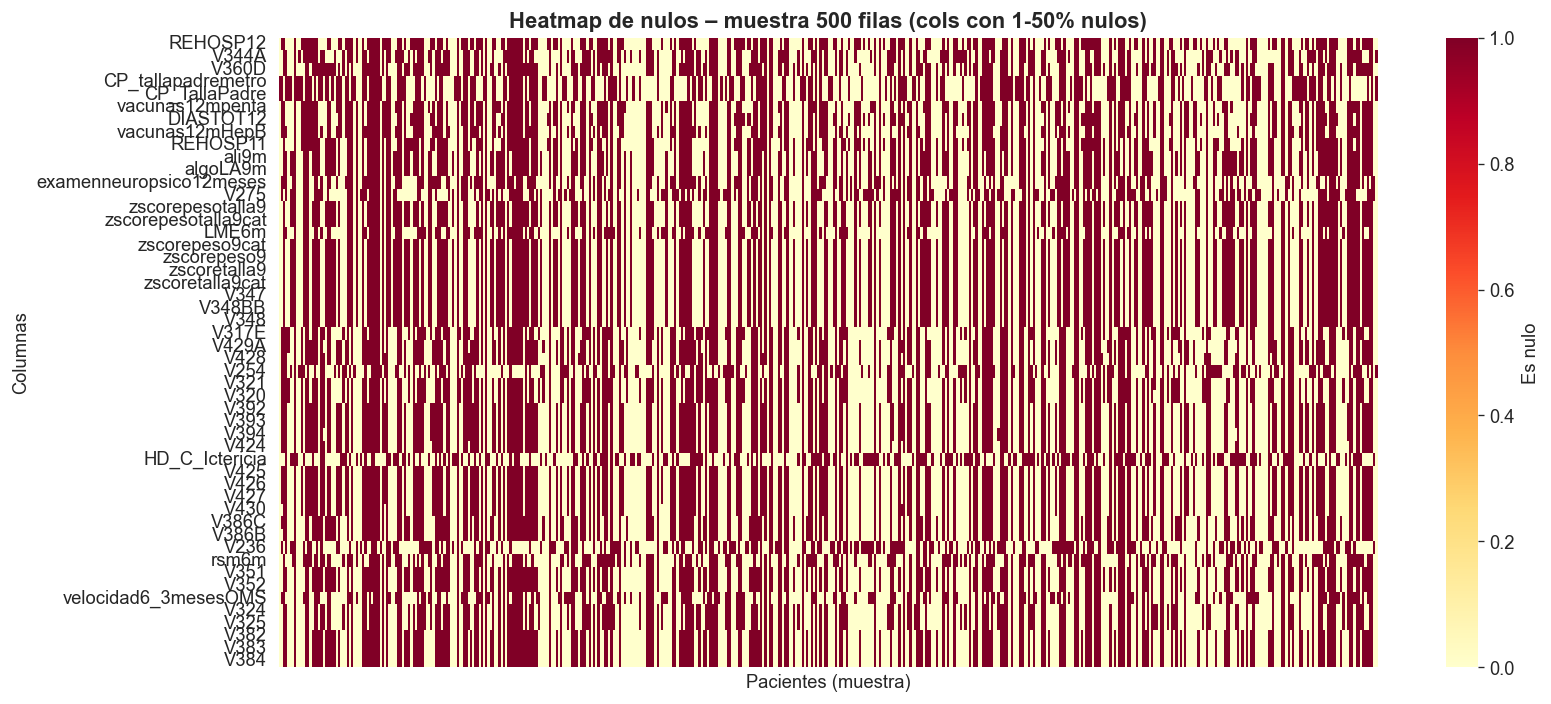

In [5]:

null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

drop_cols    = null_pct[null_pct > 75].index.tolist()
eval_cols    = null_pct[(null_pct > 50) & (null_pct <= 75)].index.tolist()
impute_med   = null_pct[(null_pct > 0) & (null_pct <= 50)].index.tolist()
complete_cols = null_pct[null_pct == 0].index.tolist()

print("=== ESTRATEGIA RECOMENDADA PARA MANEJO DE NULOS ===\n")
print(f"✅ Columnas completas (0% nulos)         : {len(complete_cols)} cols → Mantener")
print(f"🟡 Columnas con 1-50% nulos              : {len(impute_med)} cols → Imputar (media/mediana/moda)")
print(f"🟠 Columnas con 51-75% nulos             : {len(eval_cols)} cols → Evaluar relevancia clínica")
print(f"🔴 Columnas con >75% nulos               : {len(drop_cols)} cols → Candidatas a ELIMINAR")

print(f"\n📌 Columnas a eliminar (>75% nulos):")
for c in drop_cols[:15]:
    print(f"   - {c}: {null_pct[c]:.1f}%")
if len(drop_cols) > 15:
    print(f"   ... y {len(drop_cols)-15} más")

print(f"\n📌 Columnas clave con nulos bajos (conservar con imputación):")
key_check = ['gestasal', 'gestacat', 'menosde31sem', 'SGAprema', 'gestasalsindecimales',
             'gestaentradacat', 'edadmatcat', 'CP_edadmaterna']
for c in key_check:
    if c in null_pct.index:
        print(f"   - {c}: {null_pct[c]:.1f}% nulos")

# Heatmap de nulos para columnas con < 50% de nulos (muestra de 50 cols)
cols_sample = null_pct[(null_pct > 0) & (null_pct <= 50)].head(50).index
null_matrix = df[cols_sample].isnull().sample(500, random_state=42)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(null_matrix.T, cmap='YlOrRd', cbar_kws={'label': 'Es nulo'},
            xticklabels=False, yticklabels=True, ax=ax)
ax.set_title('Heatmap de nulos – muestra 500 filas (cols con 1-50% nulos)', fontweight='bold')
ax.set_xlabel('Pacientes (muestra)')
ax.set_ylabel('Columnas')
plt.tight_layout()
plt.savefig('/Users/herjimenez/Documents/MAESTRIA/PROYECTOS/Trabajo de grado/eda_04_heatmap_nulos.png',
            bbox_inches='tight')
plt.show()


## 5. Distribución de Variables Numéricas Clave

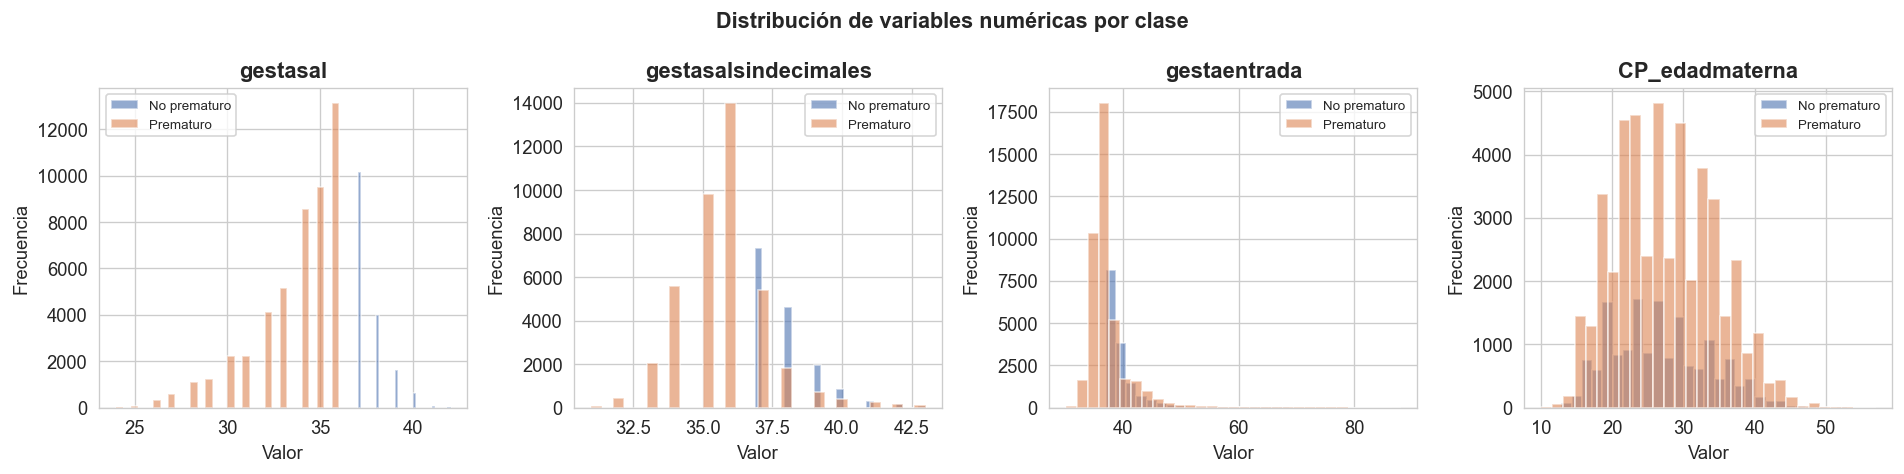

In [6]:

num_vars = ['gestasal', 'gestasalsindecimales', 'gestaentrada', 'CP_edadmaterna']
for col in num_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')

fig, axes = plt.subplots(1, len(num_vars), figsize=(16, 4))
colors_by_class = {0: '#4C72B0', 1: '#DD8452'}
labels = {0: 'No prematuro', 1: 'Prematuro'}

for i, col in enumerate(num_vars):
    for cls in [0, 1]:
        data = df[df['preterm'] == cls][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.6,
                     color=colors_by_class[cls], label=labels[cls], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/herjimenez/Documents/MAESTRIA/PROYECTOS/Trabajo de grado/eda_05_distribuciones.png',
            bbox_inches='tight')
plt.show()


## 6. Resumen y Recomendaciones

In [7]:

print("=" * 60)
print("RESUMEN EDA - Dataset KMC Malnutrición")
print("=" * 60)

df['preterm'] = pd.to_numeric(df['preterm'], errors='coerce')
counts = df['preterm'].value_counts()

print(f"\n📊 DATASET")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]:,}")

print(f"\n🎯 VARIABLE OBJETIVO: preterm")
print(f"   Prematuro (1)    : {counts.get(1,0):>6,} ({counts.get(1,0)/len(df)*100:.1f}%)")
print(f"   No prematuro (0) : {counts.get(0,0):>6,} ({counts.get(0,0)/len(df)*100:.1f}%)")
print(f"   ⚠️  Desbalance de clases detectado")

null_pct = (df.isnull().sum() / len(df) * 100)
print(f"\n🔍 NULOS")
print(f"   Columnas completas (0%)   : {(null_pct == 0).sum()}")
print(f"   Columnas con 1-25%        : {((null_pct > 0) & (null_pct <= 25)).sum()}")
print(f"   Columnas con 26-50%       : {((null_pct > 25) & (null_pct <= 50)).sum()}")
print(f"   Columnas con 51-75%       : {((null_pct > 50) & (null_pct <= 75)).sum()}")
print(f"   Columnas con >75% (drop)  : {(null_pct > 75).sum()}")

print(f"\n💡 RECOMENDACIONES")
print(f"   1. Eliminar {(null_pct > 75).sum()} columnas con >75% nulos")
print(f"   2. Convertir columnas 'object' a numeric (hay valores #NULL! de SPSS)")
print(f"   3. Tratar desbalance: usar SMOTE, class_weight o undersampling")
print(f"   4. Columnas clave con pocos nulos:")
key = ['gestasal','gestacat','menosde31sem','SGAprema','preterm']
for c in key:
    print(f"      - {c}: {null_pct.get(c,0):.1f}% nulos")
print(f"   5. Validar con experto clínico cuáles vars de 51-75% son relevantes")


RESUMEN EDA - Dataset KMC Malnutrición

📊 DATASET
   Filas    : 64,801
   Columnas : 753

🎯 VARIABLE OBJETIVO: preterm
   Prematuro (1)    : 48,320 (74.6%)
   No prematuro (0) : 16,465 (25.4%)
   ⚠️  Desbalance de clases detectado



🔍 NULOS
   Columnas completas (0%)   : 1
   Columnas con 1-25%        : 261
   Columnas con 26-50%       : 181
   Columnas con 51-75%       : 226
   Columnas con >75% (drop)  : 84

💡 RECOMENDACIONES
   1. Eliminar 84 columnas con >75% nulos
   2. Convertir columnas 'object' a numeric (hay valores #NULL! de SPSS)
   3. Tratar desbalance: usar SMOTE, class_weight o undersampling
   4. Columnas clave con pocos nulos:
      - gestasal: 0.0% nulos
      - gestacat: 0.7% nulos
      - menosde31sem: 0.0% nulos
      - SGAprema: 3.7% nulos
      - preterm: 0.0% nulos
   5. Validar con experto clínico cuáles vars de 51-75% son relevantes
